# Text Preprocessing

### 0. Create Data Sets

In [3]:
import pandas as pd

data = [
    "When life gives you lemons, make lemonade! 🙂",
    "She bought 2 lemons for $1 at Maven Market.",
    "A dozen lemons will make a gallon of lemonade. [AllRecipes]",
    "lemon, lemon, lemons, lemon, lemon, lemons",
    "He's running to the market to get a lemon — there's a great sale today.",
    "Does Maven Market carry Eureka lemons or Meyer lemons?",
    "An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",
    "iced tea is my favorite"    
]

pd. set_option('display.max_colwidth', None)

data_df = pd.DataFrame(data, columns=["sentence"])
data_df

,sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [4]:
test = [
    "We're going to start this course with traditional NLP applications.",
    "Then we'll move on to modern NLP theory.",
    "Finally, we'll wrap things up with modern NLP applications."
]

test_series = pd.Series(test)
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

## 1. Text Preprocessing with Pandas

In [5]:
df = data_df.copy()
df

,sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [6]:
df['sentence_clean'] = df['sentence'].str.lower()
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂","when life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.,she bought 2 lemons for $1 at maven market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],a dozen lemons will make a gallon of lemonade. [allrecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons","lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.,he's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?,does maven market carry eureka lemons or meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]","an arnold palmer is half lemonade, half iced tea. [wikipedia]"
7,iced tea is my favorite,iced tea is my favorite


In [7]:
df['sentence_clean'] = df['sentence'].str.replace(r'\[.*?\]', '', regex=True)
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂","When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],A dozen lemons will make a gallon of lemonade.
3,"lemon, lemon, lemons, lemon, lemon, lemons","lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]","An Arnold Palmer is half lemonade, half iced tea."
7,iced tea is my favorite,iced tea is my favorite


In [8]:
df['sentence_clean'] = df['sentence_clean'].str.replace(r'[^\w\s]', '', regex=True)
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂",When life gives you lemons make lemonade
1,She bought 2 lemons for $1 at Maven Market.,She bought 2 lemons for 1 at Maven Market
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],A dozen lemons will make a gallon of lemonade
3,"lemon, lemon, lemons, lemon, lemon, lemons",lemon lemon lemons lemon lemon lemons
4,He's running to the market to get a lemon — there's a great sale today.,Hes running to the market to get a lemon theres a great sale today
5,Does Maven Market carry Eureka lemons or Meyer lemons?,Does Maven Market carry Eureka lemons or Meyer lemons
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",An Arnold Palmer is half lemonade half iced tea
7,iced tea is my favorite,iced tea is my favorite


### Create a lower_replace function

In [12]:
def lower_replace (series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'\[^\w\s]', '', regex=True)
    return output

In [13]:
lower_replace(test_series)

0    we're going to start this course with traditional nlp applications.
1                               then we'll move on to modern nlp theory.
2            finally, we'll wrap things up with modern nlp applications.
dtype: object

In [14]:
lower_replace(df.sentence_clean)

0                              when life gives you lemons make lemonade 
1                              she bought 2 lemons for 1 at maven market
2                         a dozen lemons will make a gallon of lemonade 
3                                  lemon lemon lemons lemon lemon lemons
4    hes running to the market to get a lemon  theres a great sale today
5                  does maven market carry eureka lemons or meyer lemons
6                       an arnold palmer is half lemonade half iced tea 
7                                                iced tea is my favorite
Name: sentence_clean, dtype: object

# 2. Text Preprocessing with SpaCy

In [15]:
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂",When life gives you lemons make lemonade
1,She bought 2 lemons for $1 at Maven Market.,She bought 2 lemons for 1 at Maven Market
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],A dozen lemons will make a gallon of lemonade
3,"lemon, lemon, lemons, lemon, lemon, lemons",lemon lemon lemons lemon lemon lemons
4,He's running to the market to get a lemon — there's a great sale today.,Hes running to the market to get a lemon theres a great sale today
5,Does Maven Market carry Eureka lemons or Meyer lemons?,Does Maven Market carry Eureka lemons or Meyer lemons
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",An Arnold Palmer is half lemonade half iced tea
7,iced tea is my favorite,iced tea is my favorite


In [17]:
import spacy
nlp=spacy.load('en_core_web_sm')

C:\Users\rahul\anaconda3\envs\nlp_basics\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.2). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [19]:
phrase = df.sentence_clean[0]
phrase

'When life gives you lemons make lemonade '

In [20]:
doc = nlp(phrase)
doc

When life gives you lemons make lemonade 

In [21]:
[token.lemma_ for token in doc]

['when', 'life', 'give', 'you', 'lemon', 'make', 'lemonade']

In [24]:
norm = [token.lemma_ for token in doc if not token.is_stop]
norm

['life', 'give', 'lemon', 'lemonade']

In [25]:
list(nlp.Defaults.stop_words)[:10]

['due',
 'more',
 'while',
 'move',
 'sometime',
 'the',
 'six',
 'toward',
 '‘d',
 'myself']

In [29]:
' '.join(norm)

'life give lemon lemonade'

### Create a token_lemma_nonstop function

In [30]:
def token_lemma_nonstop(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output

In [31]:
test_series.apply(token_lemma_nonstop)

0    go start course traditional NLP application .
1                              modern NLP theory .
2    finally , wrap thing modern NLP application .
dtype: object

In [33]:
lower_replace(df.sentence_clean).apply(token_lemma_nonstop)

0                       life give lemon lemonade
1                     buy 2 lemon 1 maven market
2                    dozen lemon gallon lemonade
3            lemon lemon lemon lemon lemon lemon
4        s run market lemon   s great sale today
5    maven market carry eureka lemon meyer lemon
6       arnold palmer half lemonade half ice tea
7                               ice tea favorite
Name: sentence_clean, dtype: object

### Parts of speech tagging

In [35]:
phrase2 = lower_replace(df.sentence_clean).apply(token_lemma_nonstop) [0]
phrase2

'life give lemon lemonade'

In [36]:
doc2 =nlp(phrase2)
doc2

life give lemon lemonade

In [38]:
pos = [(token.text, token.pos_) for token in doc2]
pos

[('life', 'NOUN'), ('give', 'VERB'), ('lemon', 'NOUN'), ('lemonade', 'PROPN')]

In [40]:
nouns = [(token.text) for token in doc2 if token.pos_ in ['NOUN', 'PROPN']]
nouns

['life', 'lemon', 'lemonade']

In [41]:
' '.join(nouns)

'life lemon lemonade'

### Create a filter_pos function

In [42]:
def filter_pos(text, pos_list=['NOUN', 'PROPN']):
    doc = nlp(text)
    output = [(token.text) for token in doc if token.pos_ in pos_list]
    output = ' '.join(output)
    return output

In [43]:
test_series.apply(filter_pos)

0    course NLP applications
1                 NLP theory
2    things NLP applications
dtype: object

In [45]:
lower_replace(df.sentence_clean).apply(token_lemma_nonstop).apply(filter_pos)

0                    life lemon lemonade
1                     lemon maven market
2            dozen lemon gallon lemonade
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5        maven market eureka lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence_clean, dtype: object

In [46]:
lower_replace(df.sentence_clean).apply(filter_pos).apply(token_lemma_nonstop)

0              life lemon lemonade
1               lemon maven market
2      dozen lemon gallon lemonade
3    lemon lemon lemon lemon lemon
4          market lemon sale today
5        market eureka lemon lemon
6              palmer lemonade tea
7                              tea
Name: sentence_clean, dtype: object

# 3. Create an NLP Pipeline

In [51]:
def lower_replace (series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'\[^\w\s]', '', regex=True)
    return output

def token_lemma_nonstop(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output

def filter_pos(text, pos_list=['NOUN', 'PROPN']):
    doc = nlp(text)
    output = [(token.text) for token in doc if token.pos_ in pos_list]
    output = ' '.join(output)
    return output

In [52]:
def nlp_pipeline(series):
    output = lower_replace(series)
    output = output.apply(token_lemma_nonstop)
    output = output.apply(filter_pos)
    return output

In [53]:
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

In [54]:
nlp_pipeline(test_series)

0               nlp application
1                    nlp theory
2    wrap thing nlp application
dtype: object

In [55]:
df.sentence

0                               When life gives you lemons, make lemonade! 🙂
1                                She bought 2 lemons for $1 at Maven Market.
2                A dozen lemons will make a gallon of lemonade. [AllRecipes]
3                                 lemon, lemon, lemons, lemon, lemon, lemons
4    He's running to the market to get a lemon — there's a great sale today.
5                     Does Maven Market carry Eureka lemons or Meyer lemons?
6              An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]
7                                                    iced tea is my favorite
Name: sentence, dtype: object

In [56]:
text_clean = nlp_pipeline(df.sentence)
text_clean

0              life lemon lemonade 🙂
1                 lemon maven market
2        dozen lemon gallon lemonade
3      lemon lemon lemon lemon lemon
4            market lemon sale today
5    maven market eureka lemon lemon
6                palmer lemonade tea
7                   ice tea favorite
Name: sentence, dtype: object

### Save your cleaned data as pickle file - OPTIONAL

In [57]:
pd.to_pickle(text_clean, 'text_clean.pkl')

# 4. Count Vectorizer

In [58]:
series = pd.read_pickle('text_clean.pkl')
series

0              life lemon lemonade 🙂
1                 lemon maven market
2        dozen lemon gallon lemonade
3      lemon lemon lemon lemon lemon
4            market lemon sale today
5    maven market eureka lemon lemon
6                palmer lemonade tea
7                   ice tea favorite
Name: sentence, dtype: object

In [62]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
dtm = cv.fit_transform(series)
dtm_df = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
dtm_df

,dozen,eureka,favorite,gallon,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0,0,0,0,0,1,1,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,1,0,0,0,0
2,1,0,0,1,0,1,1,0,0,0,0,0,0,0
3,0,0,0,0,0,5,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,1,0,1
5,0,1,0,0,0,2,0,0,1,1,0,0,0,0
6,0,0,0,0,0,0,1,0,0,0,1,0,1,0
7,0,0,1,0,1,0,0,0,0,0,0,0,1,0


In [72]:
cv2 = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=.2, max_df=.8)
dtm2 = cv2.fit_transform(series)
dtm_df2 = pd.DataFrame(dtm2.toarray(), columns=cv2.get_feature_names_out())
dtm_df2

,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,1,0,1,0,0,0,0
1,1,0,0,1,1,1,0
2,1,0,1,0,0,0,0
3,5,4,0,0,0,0,0
4,1,0,0,1,0,0,0
5,2,1,0,1,1,1,0
6,0,0,1,0,0,0,1
7,0,0,0,0,0,0,1


### EDA with Count Vectorizer

In [73]:
term_freq = dtm_df2.sum()
term_freq

lemon           11
lemon lemon      5
lemonade         3
market           3
maven            2
maven market     2
tea              2
dtype: int64

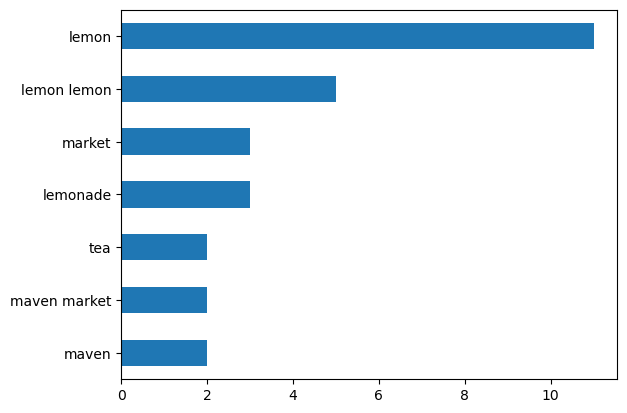

In [74]:
term_freq.sort_values().plot(kind='barh');

# 5. TF-IDF Vectorizer

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer()
tfidf = tv.fit_transform(series)
tfidf_df =pd.DataFrame(tfidf.toarray(), columns=tv.get_feature_names_out())
tfidf_df

,dozen,eureka,favorite,gallon,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.375318,0.543168,0.75107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.411442,0.000000,0.00000,0.595449,0.690041,0.000000,0.000000,0.000000,0.000000
2,0.600547,0.000000,0.000000,0.600547,0.000000,0.300100,0.434311,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.300100,0.000000,0.00000,0.434311,0.000000,0.000000,0.600547,0.000000,0.600547
5,0.000000,0.556913,0.000000,0.000000,0.000000,0.556591,0.000000,0.00000,0.402755,0.466736,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.484788,0.00000,0.000000,0.000000,0.670344,0.000000,0.561801,0.000000
7,0.000000,0.000000,0.608313,0.000000,0.608313,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.509814,0.000000


In [77]:
tv2 = TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=.2, max_df=.8)
tfidf2 = tv2.fit_transform(series)
tfidf_df2 = pd.DataFrame(tfidf2.toarray(), columns=cv2.get_feature_names_out())
tfidf_df2

,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
1,0.338644,0.000000,0.000000,0.490093,0.567948,0.567948,0.000000
2,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
3,0.597597,0.801797,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.568471,0.000000,0.000000,0.822704,0.000000,0.000000,0.000000
5,0.524634,0.439939,0.000000,0.379631,0.439939,0.439939,0.000000
6,0.000000,0.000000,0.653308,0.000000,0.000000,0.000000,0.757092
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
